# Qwen3-30B-A3B GPTQ Int4: GPTQModel vs TransformerBridge

Сравнение выполняется на **одном экземпляре одних и тех же GPTQ-весов**. Сначала измеряется чистый Hugging Face forward модели, загруженной через GPTQModel с Marlin-кернелами. Затем тот же `Qwen3MoeForCausalLM` один раз оборачивается в `TransformerBridge` и измеряется повторно.

Метрики:
- latency полного forward для batch size 1;
- throughput через `PerformanceEvaluator`;
- CUDA/CPU operator profile;
- агрегированный профиль компонентов Bridge (attention и MoE).

> После создания Bridge исходная HF-модель модифицирована in-place. Ячейку создания Bridge нельзя запускать повторно без перезагрузки kernel и GPTQModel.


In [1]:
# CUDA_VISIBLE_DEVICES нужно задавать до import torch.
import os
PHYSICAL_GPU = "3"
if PHYSICAL_GPU is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = PHYSICAL_GPU
os.environ.setdefault("HF_HUB_CACHE", "/glazkov-dev/.cache")
# os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")


'/glazkov-dev/.cache'

In [ ]:
import gc
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn
from torch.profiler import ProfilerActivity, profile, record_function
from torch.utils.data import TensorDataset
from transformers import AutoTokenizer
from gptqmodel import GPTQModel

sys.path.insert(0, "/glazkov-dev")
from utils.PerformanceEvaluator import PerformanceEvaluator
from transformer_lens.model_bridge import TransformerBridge
from transformer_lens.model_bridge.generalized_components.base import GeneralizedComponent

print("torch:", torch.__version__)
print("visible CUDA devices:", torch.cuda.device_count())
assert torch.cuda.is_available(), "Для этого benchmark требуется CUDA"
DEVICE = torch.device("cuda:0")
print("benchmark device:", torch.cuda.get_device_name(DEVICE))


WARN  Python GIL is enabled: Multi-gpu quant acceleration for MoE models is sub-optimal and multi-core accelerated cpu packing is also disabled. We recommend Python >= 3.13.3t with Pytorch > 2.8 for mult-gpu quantization and multi-cpu packing with env `PYTHON_GIL=0`.


WARN  Feature `utils/Perplexity` requires Python < 3.14 and Python GIL enabled and Python >= 3.13.3T (T for Threading-Free edition of Python) plus Torch 2.8. Feature is currently skipped/disabled.


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
[W715 16:11:49.598838059 Context.cpp:424] Warning: torch.backends.cuda.preferred_linalg_library is an experimental feature. If you see any error or unexpected behavior when this flag is set please file an issue on GitHub. (function operator())


INFO  ENV: Auto setting PYTORCH_ALLOC_CONF='expandable_segments:True,max_split_size_mb:256,garbage_collection_threshold:0.7' for memory saving.


INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          


INFO:datasets:TensorFlow version 2.21.0 available.


INFO  

┌─────────────┐    ┌────────────────────────┐    ┌────────────┐    ┌─────────┐
│ GPT-QModel  │ -> │ ▓▓▓▓▓▓▓▓▓▓▓▓ 16bit     │ -> │ ▒▒▒▒ 8bit  │ -> │ ░░ 4bit │
└─────────────┘    └────────────────────────┘    └────────────┘    └─────────┘
GPT-QModel   : 5.8.0
Transformers : 5.5.1
Torch        : 2.10.0+cu128
Triton       : 3.6.0


torch: 2.10.0+cu128
visible CUDA devices: 1
benchmark device: NVIDIA A100-PCIE-40GB


## Конфигурация

Checkpoint уже содержит GPTQ Int4-веса. GPTQModel/Defuser преобразует fused Qwen3 MoE в `LinearQwen3MoeSparseMoeBlock`, а проекции attention и экспертов загружаются как `MarlinQuantLinear`. Дополнительная BitsAndBytes-квантизация не используется.


In [3]:
MODEL_ID = "Qwen/Qwen3-30B-A3B-GPTQ-Int4"
DTYPE = torch.float16
SEQ_LEN = 512
BATCH_SIZE = 4
N_BATCHES = 8
THROUGHPUT_REPEATS = 3
PROFILE_STEPS = 3

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

prompts = [
    "Explain mixture-of-experts routing in a transformer.",
    "Write a short comparison of quantization and pruning.",
    "Why does attention use a key-value cache during generation?",
    "Describe the difference between latency and throughput.",
] * (BATCH_SIZE * N_BATCHES // 4)
encoded = tokenizer(
    prompts,
    padding="max_length",
    truncation=True,
    max_length=SEQ_LEN,
    return_tensors="pt",
)
dataset = TensorDataset(encoded["input_ids"], encoded["attention_mask"])
print(encoded["input_ids"].shape)


INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-30B-A3B-GPTQ-Int4/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-30B-A3B-GPTQ-Int4/9b534e4318b7ebc3c961a839f13eb18b1833f441/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-30B-A3B-GPTQ-Int4/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-30B-A3B-GPTQ-Int4/9b534e4318b7ebc3c961a839f13eb18b1833f441/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen3-30B-A3B-GPTQ-Int4/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen3-30B-A3B-GPTQ-Int4/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO:httpx:H

torch.Size([32, 512])


## Адаптеры для PerformanceEvaluator

`PerformanceEvaluator` ожидает `model(tensor)` и вызывает `.to(device)`. Обёртка делает `.to()` no-op, поскольку GPTQ-модель уже размещена на GPU, и строит `attention_mask` из padding. Сырой `throughput_eval()` возвращает ms/sample; ниже значение явно переводится в samples/s.


In [4]:
class LLMForwardAdapter(nn.Module):
    def __init__(self, backend, pad_token_id: int, is_bridge: bool):
        super().__init__()
        self.backend = backend
        self.pad_token_id = pad_token_id
        self.is_bridge = is_bridge

    def to(self, *args, **kwargs):
        return self

    def forward(self, input_ids):
        attention_mask = input_ids.ne(self.pad_token_id).long()
        if self.is_bridge:
            return self.backend(
                input_ids,
                attention_mask=attention_mask,
                return_type="logits",
                use_cache=False,
                logits_to_keep=1,
            )
        return self.backend(
            input_ids=input_ids,
            attention_mask=attention_mask,
            use_cache=False,
            logits_to_keep=1,
            return_dict=True,
        ).logits


def benchmark_with_evaluator(adapter, label):
    evaluator = PerformanceEvaluator(
        adapter,
        data=dataset,
        device=DEVICE,
        batch_size=BATCH_SIZE,
        n_batches=N_BATCHES,
    )
    evaluator.warm_up_cuda(n_batches=3)
    latency_ms = evaluator.latency_eval()
    ms_per_sample = evaluator.throughput_eval(THROUGHPUT_REPEATS)
    result = {
        "backend": label,
        "latency_ms_mean": float(np.mean(latency_ms)),
        "latency_ms_std": float(np.std(latency_ms)),
        "ms_per_sample_mean": float(np.mean(ms_per_sample)),
        "ms_per_sample_std": float(np.std(ms_per_sample)),
        "throughput_samples_s": float(1000.0 / np.mean(ms_per_sample)),
    }
    return result, evaluator


## 1. Чистый GPTQModel

Модель загружается один раз. До benchmark проверяется, что Defuser создал линейный MoE, а GPTQ-проекции действительно используют Marlin.


In [5]:
gptq_model = GPTQModel.load(
    MODEL_ID,
    device="cuda:0",
    dtype=DTYPE,
    profile="low_memory",
)
hf_model = gptq_model.model
hf_model.eval()

attn = hf_model.model.layers[0].self_attn
mlp = hf_model.model.layers[0].mlp
print("attention:", type(attn).__name__)
print("q_proj:", type(attn.q_proj).__name__)
print("MoE:", type(mlp).__name__)
print("expert gate_proj:", type(mlp.experts[0].gate_proj).__name__)
assert "Marlin" in type(attn.q_proj).__name__
assert "Marlin" in type(mlp.experts[0].gate_proj).__name__

gptq_memory_gib = torch.cuda.memory_allocated(DEVICE) / 2**30
gptq_adapter = LLMForwardAdapter(hf_model, tokenizer.pad_token_id, is_bridge=False)
gptq_result, gptq_evaluator = benchmark_with_evaluator(
    gptq_adapter, "GPTQModel (Marlin)"
)
pd.DataFrame([gptq_result])


INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-30B-A3B-GPTQ-Int4/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-30B-A3B-GPTQ-Int4/9b534e4318b7ebc3c961a839f13eb18b1833f441/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-30B-A3B-GPTQ-Int4/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-30B-A3B-GPTQ-Int4/9b534e4318b7ebc3c961a839f13eb18b1833f441/config.json "HTTP/1.1 200 OK"


from_quantized: adapter: None


INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen3-30B-A3B-GPTQ-Int4/revision/main "HTTP/1.1 200 OK"


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

INFO  Patched transformers.models.qwen3_moe.modeling_qwen3_moe.Qwen3MoeSparseMoeBlock -> defuser.modeling.unfused_moe.qwen3_moe.LinearQwen3MoeSparseMoeBlock


...

INFO  Model: Updated `generation_config`: GenerationConfig {
  "bos_token_id": 151643,
  "do_sample": true,
  "eos_token_id": [
    151645,
    151643
  ],
  "temperature": 0.6,
  "top_k": 20,
  "top_p": 0.95
}



INFO  Kernel: loaded -> `[MarlinQuantLinear]`                                  


attention: Qwen3MoeAttention
q_proj: MarlinQuantLinear
MoE: LinearQwen3MoeSparseMoeBlock
expert gate_proj: MarlinQuantLinear


warming: 8it [00:11,  1.42s/it]                       
throughput eval batches: 100%|██████████| 8/8 [00:32<00:00,  4.05s/batch]


,backend,latency_ms_mean,latency_ms_std,ms_per_sample_mean,ms_per_sample_std,throughput_samples_s
0,GPTQModel (Marlin),893.718147,9.850956,337.585977,2.971866,2.962208


## 2. GPTQModel + TransformerBridge

Bridge оборачивает **тот же** `Qwen3MoeForCausalLM`; веса не загружаются повторно. Защитная проверка не позволяет случайно обернуть уже модифицированную модель второй раз.


In [6]:
already_bridged = [
    name for name, module in hf_model.named_modules()
    if isinstance(module, GeneralizedComponent)
]
assert not already_bridged, f"HF model уже обёрнута Bridge: {already_bridged[0]}"

bridge = TransformerBridge.boot_transformers(
    MODEL_ID,
    hf_model=hf_model,
    tokenizer=tokenizer,
    dtype=DTYPE,
)
bridge.eval()
bridge_memory_gib = torch.cuda.memory_allocated(DEVICE) / 2**30
bridge_adapter = LLMForwardAdapter(bridge, tokenizer.pad_token_id, is_bridge=True)
bridge_result, bridge_evaluator = benchmark_with_evaluator(
    bridge_adapter, "GPTQModel + TransformerBridge"
)
pd.DataFrame([bridge_result])


warming: 8it [00:11,  1.42s/it]                       
throughput eval batches: 100%|██████████| 8/8 [00:33<00:00,  4.21s/batch]


,backend,latency_ms_mean,latency_ms_std,ms_per_sample_mean,ms_per_sample_std,throughput_samples_s
0,GPTQModel + TransformerBridge,935.519653,19.708504,350.65509,1.298649,2.851805


## Детальный профиль Bridge

`record_function`-метки агрегируют время всех attention и MoE-компонентов без послойной таблицы. Профилирование запускается отдельно и не входит в основной benchmark.


In [7]:
def install_component_ranges(bridge_model):
    handles = []
    active_ranges = {}

    def add_range(module, label):
        def pre_hook(mod, args):
            ctx = record_function(label)
            ctx.__enter__()
            active_ranges[id(mod)] = ctx

        def post_hook(mod, args, output):
            active_ranges.pop(id(mod)).__exit__(None, None, None)

        handles.append(module.register_forward_pre_hook(pre_hook))
        handles.append(module.register_forward_hook(post_hook))

    for block in bridge_model.blocks:
        add_range(block.attn, "bridge_component::attention")
        add_range(block.mlp, "bridge_component::moe")
    return handles


profile_batch = encoded["input_ids"][:BATCH_SIZE].to(DEVICE)
for _ in range(2):
    with torch.inference_mode():
        bridge_adapter(profile_batch)
torch.cuda.synchronize()

range_handles = install_component_ranges(bridge)
with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True,
    profile_memory=True,
    with_stack=False,
) as bridge_profiler:
    for _ in range(PROFILE_STEPS):
        with record_function("bridge_model_inference"):
            with torch.inference_mode():
                bridge_adapter(profile_batch)
        torch.cuda.synchronize()

for handle in range_handles:
    handle.remove()

print(bridge_profiler.key_averages().table(sort_by="cpu_time_total", row_limit=25))
print(bridge_profiler.key_averages().table(sort_by="self_cuda_time_total", row_limit=25))


/glazkov-dev/.venv/lib/python3.10/site-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                 bridge_model_inference         1.20%      84.507ms        99.99%        7.015s        2.338s       0.000us         0.00%        1.087s     362.238ms           0 B           0 B           0 B     -45.35 G

In [8]:
def profiler_frame(prof):
    rows = []
    for event in prof.key_averages():
        rows.append({
            "name": event.key,
            "calls": event.count,
            "cpu_time_total_ms": event.cpu_time_total / 1000.0,
            "self_cpu_time_total_ms": event.self_cpu_time_total / 1000.0,
            "cuda_time_total_ms": getattr(event, "device_time_total", 0.0) / 1000.0,
            "self_cuda_time_total_ms": getattr(event, "self_device_time_total", 0.0) / 1000.0,
        })
    return pd.DataFrame(rows)


bridge_profile_df = profiler_frame(bridge_profiler)
component_profile = (
    bridge_profile_df[bridge_profile_df["name"].str.startswith("bridge_component::")]
    .sort_values("cuda_time_total_ms", ascending=False)
)
display(component_profile)

top_cuda_ops = bridge_profile_df.nlargest(20, "self_cuda_time_total_ms")
display(top_cuda_ops[["name", "calls", "self_cuda_time_total_ms", "cpu_time_total_ms"]])

trace_path = Path(
    "/glazkov-dev/LoRa-Transfer-Pruning/experiments/qwen3_gptq_bridge_trace.json"
)
bridge_profiler.export_chrome_trace(str(trace_path))
print("Chrome trace:", trace_path)


,name,calls,cpu_time_total_ms,self_cpu_time_total_ms,cuda_time_total_ms,self_cuda_time_total_ms
109,bridge_component::moe,144,0.000000,0.000000,6457.473747,6457.473747
105,bridge_component::moe,144,6514.462473,2370.949314,745.964213,0.000000
82,bridge_component::attention,144,0.000000,0.000000,390.030832,390.030832
79,bridge_component::attention,144,322.434461,137.998053,274.083959,0.000000


,name,calls,self_cuda_time_total_ms,cpu_time_total_ms
4,bridge_model_inference,3,7015.352187,0.000000
109,bridge_component::moe,144,6457.473747,0.000000
153,"void marlin::Marlin<__half, 1125899907892224l,...",22365,471.287301,0.000000
83,"void marlin::Marlin<__half, 1125899907892224l,...",7515,415.647408,0.000000
82,bridge_component::attention,144,390.030832,0.000000
130,aten::nonzero,11172,202.097223,1541.798241
151,aten::index_add_,11028,197.988852,169.624626
62,aten::mul,24519,169.979998,368.962091
147,"void marlin::Marlin<__half, 1125899907892224l,...",3510,137.304558,0.000000
9,aten::copy_,13794,136.786337,207.954530


Chrome trace: /glazkov-dev/LoRa-Transfer-Pruning/experiments/qwen3_gptq_bridge_trace.json


## Сводная таблица и графики


,latency_ms_mean,latency_ms_std,ms_per_sample_mean,ms_per_sample_std,throughput_samples_s,latency_overhead_pct,throughput_change_pct,allocated_memory_gib
backend,,,,,,,,
GPTQModel (Marlin),893.718,9.851,337.586,2.972,2.962,0.000,0.000,15.558
GPTQModel + TransformerBridge,935.520,19.709,350.655,1.299,2.852,4.677,-3.727,15.566


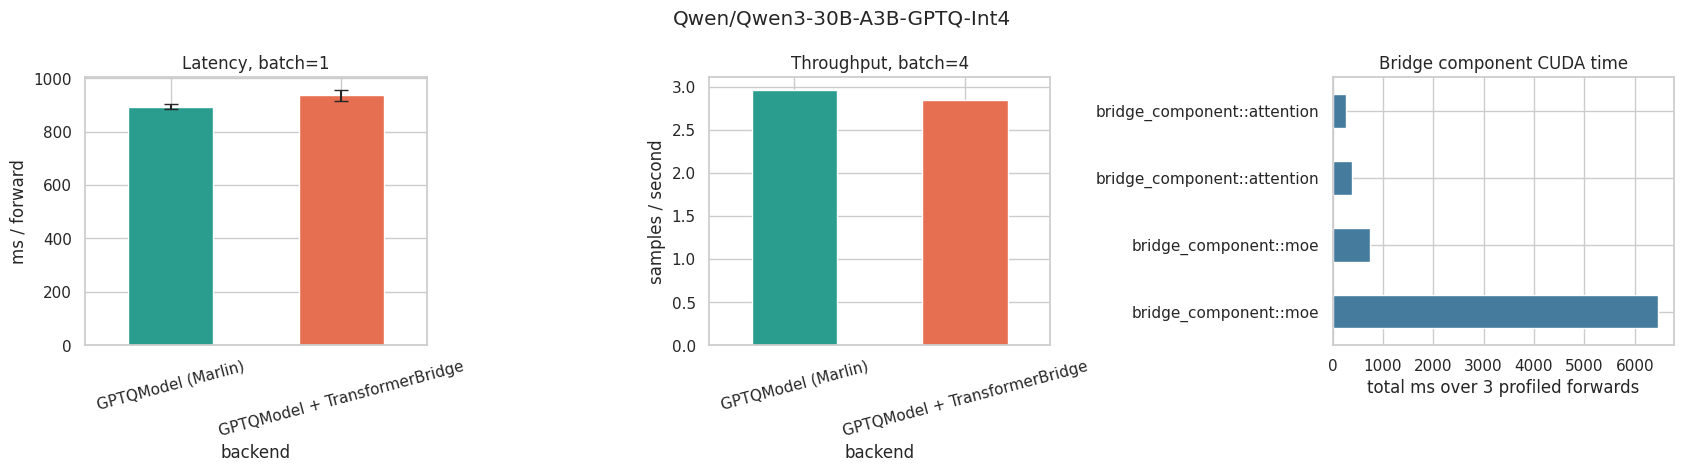

In [15]:
results = pd.DataFrame([gptq_result, bridge_result]).set_index("backend")
baseline = "GPTQModel (Marlin)"
results["latency_overhead_pct"] = (
    results["latency_ms_mean"] / results.loc[baseline, "latency_ms_mean"] - 1
) * 100
results["throughput_change_pct"] = (
    results["throughput_samples_s"] / results.loc[baseline, "throughput_samples_s"] - 1
) * 100
results["allocated_memory_gib"] = [gptq_memory_gib, bridge_memory_gib]
display(results.round(3))

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
plt.suptitle(MODEL_ID)

results["latency_ms_mean"].plot.bar(
    ax=axes[0],
    yerr=results["latency_ms_std"],
    capsize=5,
    color=["#2a9d8f", "#e76f51"],
)
axes[0].set_title("Latency, batch=1")
axes[0].set_ylabel("ms / forward")
axes[0].tick_params(axis="x", rotation=15)

results["throughput_samples_s"].plot.bar(
    ax=axes[1], color=["#2a9d8f", "#e76f51"]
)
axes[1].set_title(f"Throughput, batch={BATCH_SIZE}")
axes[1].set_ylabel("samples / second")
axes[1].tick_params(axis="x", rotation=15)

if not component_profile.empty:
    component_profile.set_index("name")["cuda_time_total_ms"].plot.barh(
        ax=axes[2], color="#457b9d"
    )
axes[2].set_title("Bridge component CUDA time")
axes[2].set_xlabel(f"total ms over {PROFILE_STEPS} profiled forwards")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()


/tmp/ipykernel_617878/399912765.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


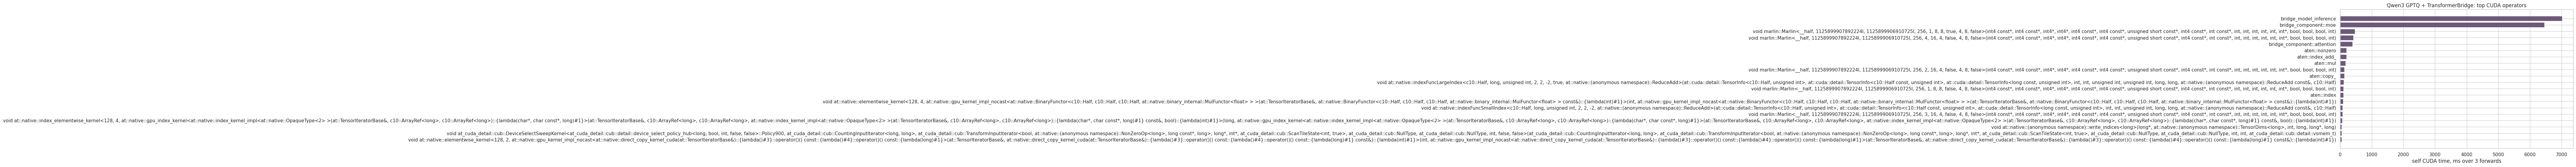

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_ops = top_cuda_ops.sort_values("self_cuda_time_total_ms")
ax.barh(plot_ops["name"], plot_ops["self_cuda_time_total_ms"], color="#6d597a")
ax.set_title("Qwen3 GPTQ + TransformerBridge: top CUDA operators")
ax.set_xlabel(f"self CUDA time, ms over {PROFILE_STEPS} forwards")
plt.tight_layout()
plt.show()
